In [18]:
from huggingface_hub import hf_hub_download
from ultralytics import YOLO
from supervision import Detections
from PIL import Image
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import json
import pandas as pd

In [9]:
model_path = hf_hub_download(repo_id="arnabdhar/YOLOv8-Face-Detection", filename="model.pt")

In [14]:
model = YOLO(model_path)

# inference
image_path = "Marriage.jpg"
image = Image.open(image_path)
output = model(image)
results = Detections.from_ultralytics(output[0])
#


0: 448x640 19 FACEs, 29.1ms
Speed: 1.5ms preprocess, 29.1ms inference, 0.3ms postprocess per image at shape (1, 3, 448, 640)


In [6]:
print(output)

[ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'FACE'}
obb: None
orig_img: array([[[253, 253, 253],
        [253, 253, 253],
        [253, 253, 253],
        ...,
        [ 42, 116, 158],
        [ 42, 113, 157],
        [ 41, 112, 156]],

       [[253, 253, 253],
        [253, 253, 253],
        [253, 253, 253],
        ...,
        [ 43, 117, 159],
        [ 43, 114, 158],
        [ 42, 113, 157]],

       [[253, 253, 253],
        [253, 253, 253],
        [253, 253, 253],
        ...,
        [ 43, 118, 157],
        [ 43, 117, 159],
        [ 42, 116, 158]],

       ...,

       [[157, 152, 151],
        [156, 151, 150],
        [156, 148, 148],
        ...,
        [ 81,  69,  41],
        [ 78,  66,  38],
        [ 76,  64,  36]],

       [[159, 154, 153],
        [158, 153, 152],
        [157, 149, 149],
        ...,
        [ 83,  71,  43],
        [ 81,  69,  41],
        [ 79, 

In [16]:
def visualize_detections(image, results, figsize=(12, 8)):
    """
    Visualize face detections on an image with bounding boxes and confidence scores.
    
    Args:
        image (PIL.Image): Input image in PIL format
        results (supervision.Detections): Detection results from the model
        figsize (tuple): Figure size for matplotlib display (width, height)
    """
    # Convert PIL Image to OpenCV format
    image_cv2 = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)

    # Draw boxes
    for box, confidence in zip(results.xyxy, results.confidence):
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(image_cv2, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(image_cv2, f"{confidence:.2f}", (x1, y1-10), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    # Convert back to RGB for display
    image_rgb = cv2.cvtColor(image_cv2, cv2.COLOR_BGR2RGB)

    # Display using matplotlib
    plt.figure(figsize=figsize)
    plt.imshow(image_rgb)
    plt.axis('off')
    plt.show()

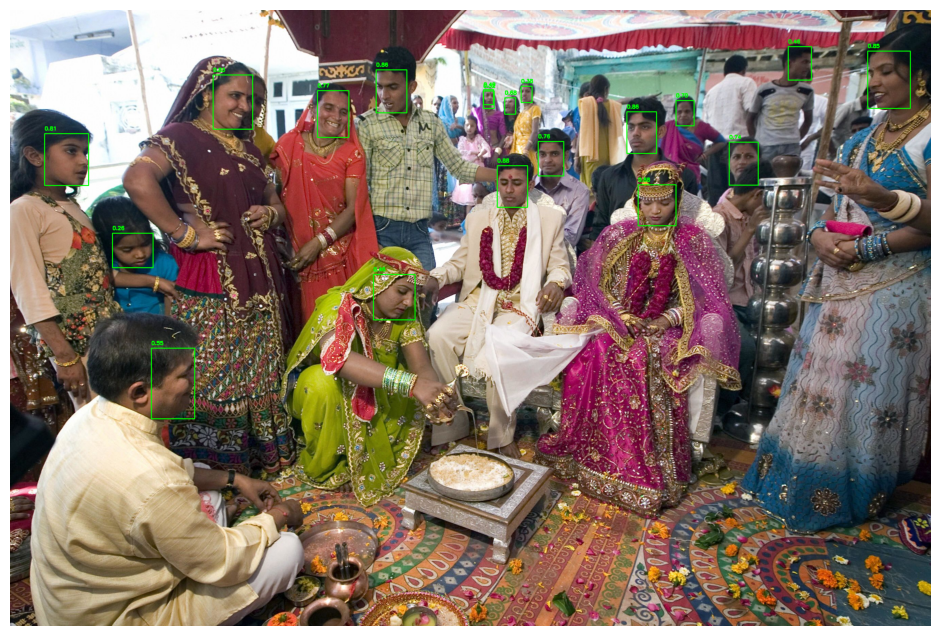

In [17]:
visualize_detections(image,results)

In [29]:
def save_faces_and_boxes(image, results, output_dir):
    """
    Save detected faces and bounding boxes to a dataset.

    :param image: Input image as a NumPy array.
    :param boxes: Detected bounding boxes (ultralytics.engine.results.Boxes).
    :param output_dir: Directory to save the dataset.
    """
    os.makedirs(output_dir, exist_ok=True)
    images_dir = os.path.join(output_dir, "images")
    os.makedirs(images_dir, exist_ok=True)

    # Initialize metadata storage
    metadata = []

    # Iterate over detected boxes
    for (i,( box,conf)) in enumerate(zip(results.xyxy,results.confidence)):  # assuming boxes.data is a tensor
        x_min, y_min, x_max, y_max = map(float, box)

        # Crop the detected face
        cropped_face = image[int(y_min):int(y_max), int(x_min):int(x_max)]

        # Save the cropped face
        image_filename = f"face_{i}.jpg"
        image_path = os.path.join(images_dir, image_filename)
        cv2.imwrite(image_path, cropped_face)
        conf = float(conf)
        # Append metadata
        metadata.append({
            "image": image_filename,
            "x_min": x_min,
            "y_min": y_min,
            "x_max": x_max,
            "y_max": y_max,
            "confidence": conf,
        })
    print(metadata)
    # Save metadata to JSON
    metadata_path = os.path.join(output_dir, "metadata.json")
    with open(metadata_path, "w") as f:
        json.dump(metadata, f, indent=4)

    # Optionally, save to CSV
    metadata_df = pd.DataFrame(metadata)
    metadata_csv_path = os.path.join(output_dir, "metadata.csv")
    metadata_df.to_csv(metadata_csv_path, index=False)

    print(f"Dataset saved to {output_dir}")

In [30]:
# Convert PIL Image to numpy array first (since the function expects a numpy array)
image_np = np.array(image)

# Call the function with an appropriate output directory
output_dir = "./detected_faces"
save_faces_and_boxes(image_np, results, output_dir)

[{'image': 'face_0.jpg', 'x_min': 1428.8966064453125, 'y_min': 456.98052978515625, 'x_max': 1517.0830078125, 'y_max': 578.2804565429688, 'confidence': 0.8818872}, {'image': 'face_1.jpg', 'x_min': 1073.887451171875, 'y_min': 175.97451782226562, 'x_max': 1163.9859619140625, 'y_max': 301.0404052734375, 'confidence': 0.863428}, {'image': 'face_2.jpg', 'x_min': 1808.548095703125, 'y_min': 298.568359375, 'x_max': 1895.655029296875, 'y_max': 420.0264587402344, 'confidence': 0.8557729}, {'image': 'face_3.jpg', 'x_min': 2514.316162109375, 'y_min': 120.56232452392578, 'x_max': 2639.41650390625, 'y_max': 288.5487976074219, 'confidence': 0.852506}, {'image': 'face_4.jpg', 'x_min': 595.4469604492188, 'y_min': 190.24807739257812, 'x_max': 711.56787109375, 'y_max': 349.5353698730469, 'confidence': 0.83071166}, {'image': 'face_5.jpg', 'x_min': 101.95909118652344, 'y_min': 362.86669921875, 'x_max': 230.97872924804688, 'y_max': 514.4884643554688, 'confidence': 0.8089235}, {'image': 'face_6.jpg', 'x_min'

TypeError: Object of type float32 is not JSON serializable